### Project 1
#### Infrastructure Investment & Jobs Act Funding Allocation

#### **Data source**: 
1) Funding allocation of the Infrastructure Investment and Jobs Act funding by State and Territory
2) Population by state data source: https://www.census.gov/data/tables/time-series/demo/popest/2020s-state-total.html
3) Political party affiliation data source: https://www.cnn.com/election/2020/results/president

#### **questions to answer:**:
1) Is the allocation equitable based on the population of each of the States and Territories, or is bias apparent?
2) Does the allocation favor the political interests of the Biden administration?

#### Loading data:

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Load the dataset:
df = pd.read_excel('IIJA FUNDING AS OF MARCH 2023.xlsx', sheet_name='Sheet1')
df_pop = pd.read_excel('NST-EST2024-CHG.xlsx', sheet_name='Sheet1')
df.head()
df_pop.head()

,States,2020_population
0,.Alabama,5033094
1,.Alaska,733017
2,.Arizona,7187135
3,.Arkansas,3014546
4,.California,39521958


We will clean and merge the two datasets:

**Note: only 51 states will be included in this study. Minor US territories will not be included.**

**Political party affiliations will be also assigned according to the data source from CNN**

In [11]:
#To standardize the state column names for merging:
df_pop['States'] = df_pop['States'].str.replace('.', '', regex=False).str.lower()

df['State, Teritory or Tribal Nation'] = df['State, Teritory or Tribal Nation'].astype(str)
df['State, Teritory or Tribal Nation'] = df['State, Teritory or Tribal Nation'].str.lower()
df.rename(columns={'State, Teritory or Tribal Nation': 'States'}, inplace=True)

#The funding dataset has a typo in Delaware, we will fix it:
df['States'] = df['States'].replace('deleware', 'delaware')

#We will perform a left join to keep all states in the funding dataset:
df_merged = df_pop.merge(df, how='left', on='States')

#Assigning political party affiliations based on the 2020 presidential election results:
demo_states = [
    "arizona",
    "california",
    "colorado",
    "connecticut",
    "delaware",
    "district of columbia",
    "georgia",
    "hawaii",
    "illinois",
    "maine",
    "maryland",
    "massachusetts",
    "michigan",
    "minnesota",
    "nevada",
    "new hampshire",
    "new jersey",
    "new mexico",
    "new york",
    "oregon",
    "pennsylvania",
    "virginia",
    "washington",
    "wisconsin"
]

df_merged['party'] = df_merged['States'].apply(lambda x: 'Democrat' if x in demo_states else 'Republican')

#Adjust the population column to millions for easier visualization:
df_merged['2020_population'] = df_merged['2020_population'] / 1_000_000
df_merged.rename(columns={'2020_population': '2020_population(millions)'}, inplace=True)

Confirming the merged dataset is free of missing values and have all 51 states:

In [12]:
print('Number of States:\n', df_merged['States'].count())
print('-'*40)
print('Missing values in each column:\n', df_merged.isnull().sum())

Number of States:
 51
----------------------------------------
Missing values in each column:
 States                       0
2020_population(millions)    0
Total (Billions)             0
party                        0
dtype: int64


In [13]:
df_merged.head()

,States,2020_population(millions),Total (Billions),party
0,alabama,5.033094,3.0,Republican
1,alaska,0.733017,3.7,Republican
2,arizona,7.187135,3.5,Democrat
3,arkansas,3.014546,2.8,Republican
4,california,39.521958,18.4,Democrat


### Exploratory Data Analysis:

Text(0.5, 1.0, 'Funding Allocation vs State Population')

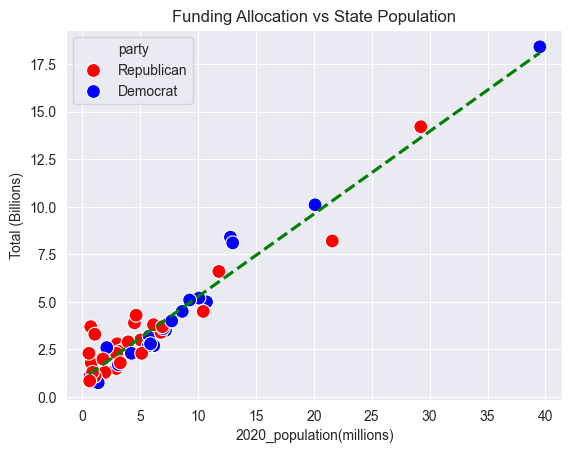

In [16]:
palette_colors = {'Democrat': 'blue', 'Republican': 'red'}
sns.scatterplot(data=df_merged, 
                x = '2020_population(millions)', 
                y = 'Total (Billions)', 
                hue = 'party', 
                palette = palette_colors,
                s = 100
                )
sns.regplot(data = df_merged, 
            x = '2020_population(millions)', 
            y = 'Total (Billions)', 
            scatter = False,
            ci = None,
            line_kws = {'color': 'green', 'linestyle': 'dashed'}
            )

sns.set_style('darkgrid')

plt.title('Funding Allocation vs State Population')

Figure 1: There is a strong linear relationship between state population and the amount of funding being given to the state. Funds are being allocated has a positive correlation with state populations.

C:\Users\godly\AppData\Local\Temp\ipykernel_29960\1136277064.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Total Funding (Billions) by Political Party')

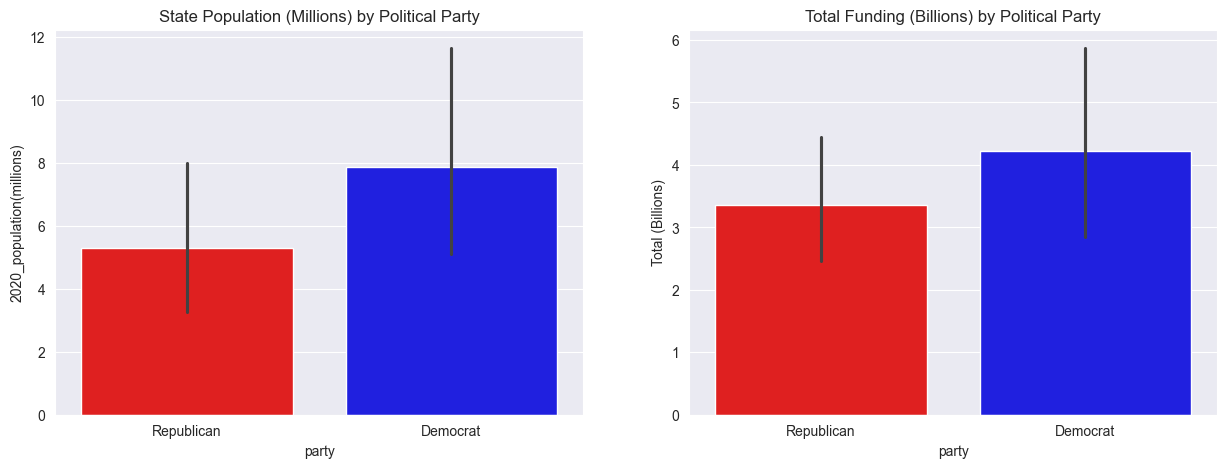

In [62]:
palette_colors = {'Democrat': 'blue', 'Republican': 'red'}
fid, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=df_merged, 
            x = 'party', 
            y = '2020_population(millions)', 
            palette = palette_colors,
            ax = axes[0]
            )
axes[0].set_title('State Population (Millions) by Political Party')
sns.barplot(data=df_merged,
            x = 'party', 
            y = 'Total (Billions)', 
            palette = palette_colors,
            hue = 'party',
            ax = axes[1]            
            )
axes[1].set_title('Total Funding (Billions) by Political Party')


Figure 2: Comparison between total funds allocated and total population by each political party. 

Both graph shows demoncratic states have more population and thus received more funding consistent with fidnings from figure 1.

In [37]:
#Calculating per capita funding and difference in state population and funding by political party:
group_total = df_merged.groupby('party')[['Total (Billions)', '2020_population(millions)']].sum()
group_total['Funding_per_capita'] = group_total['Total (Billions)'] / group_total['2020_population(millions)']

#Fund difference relative to Democratic states:
fund_diff = (group_total.loc['Democrat', 'Total (Billions)'] - group_total.loc['Republican', 'Total (Billions)']) / (group_total.loc['Republican', 'Total (Billions)'] + group_total.loc['Democrat', 'Total (Billions)']) * 100

#Population difference relative to Democratic states:
pop_diff = (group_total.loc['Democrat', '2020_population(millions)'] - group_total.loc['Republican', '2020_population(millions)']) / (group_total.loc['Republican', '2020_population(millions)'] + group_total.loc['Democrat', '2020_population(millions)']) * 100

#Per capita funding difference relative to Democratic states:
per_cap_diff = (group_total.loc['Democrat', 'Funding_per_capita'] - group_total.loc['Republican', 'Funding_per_capita']) / (((group_total.loc['Republican', 'Funding_per_capita'] + group_total.loc['Democrat', 'Funding_per_capita']))/2) * 100

print(f'Total fund difference between the two parties: {fund_diff:.1f}%')
print(f'Total population difference between the two parties: {pop_diff:.1f}%')
print(f'Per capita fund difference between the two parties: {per_cap_diff:.1f}%.\n*Note negative value indicates Republican states receive more per capita funding.')

Total fund difference between the two parties: 5.6%
Total population difference between the two parties: 13.7%
Per capita fund difference between the two parties: -16.4%.
*Note negative value indicates Republican states receive more per capita funding.


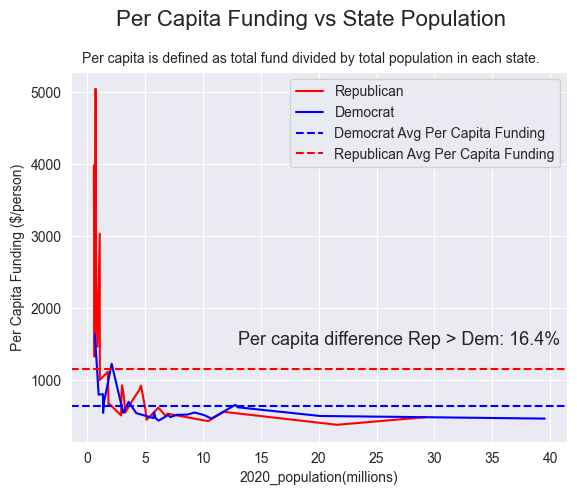

In [78]:
df_merged['per_capita_funding'] = (df_merged['Total (Billions)'] * 1_000_000_000) / (df_merged['2020_population(millions)'] * 1_000_000)
demo_avg_pc = df_merged[df_merged['party'] == 'Democrat']['per_capita_funding'].mean()
repub_avg_pc = df_merged[df_merged['party'] == 'Republican']['per_capita_funding'].mean()

palette_colors = {'Democrat': 'blue', 'Republican': 'red'}
sns.lineplot(data=df_merged,
             x = '2020_population(millions)',
             y = 'per_capita_funding',
             hue = 'party',
             palette = palette_colors
            )

plt.axhline(demo_avg_pc, color='blue', linestyle='dashed', label='Democrat Avg Per Capita Funding')
plt.axhline(repub_avg_pc, color='red', linestyle='dashed', label='Republican Avg Per Capita Funding')
plt.legend()

plt.suptitle('Per Capita Funding vs State Population', fontsize=16, y=1.01)
plt.text(0.5, 0.9, 'Per capita is defined as total fund divided by total population in each state.',
         fontsize=10, ha='center', transform=plt.gcf().transFigure)
plt.ylabel('Per Capita Funding ($/person)')
plt.text(x = 13, y = 1500, s= f'Per capita difference Rep > Dem: {-per_cap_diff:.1f}%', fontsize=13)

sns.set_style('darkgrid')
plt.show()

Figure 3: The average per-capita for republican states is higher than democratic states, indicating that funds allocated per person in republican state is higher than those allocated to demoncratic state.

Summary:
1) Is the allocation equitable based on the population of each of the States and Territories, or is bias apparent?

    Ans: Without considering political part affiliation, figure 1 shows that the funding allocations have a directly proportional relationship with the total population of the state as shown in Figure 1. The funds allocated to each state is, at least, on the scale of the state populations and the factor of bias is not apparent. However, when we consider each state's political allocation and calculated the per-capita, Republican states have on average 16.4% more per-capita versus democratic state (figure 3). From this aspect, we can see that there is a bias factor towards rewards Republican states.

2) Does the allocation favor the political interests of the Biden administration?

    Ans: This study is conducted based on the election results from 2020 when Biden won the presidency. However, funding allocation still favored Republican states despite a democratic president.